In [7]:
import numpy as np
import pyDOE as doe
from mpl_toolkits import mplot3d
from sklearn.preprocessing import MinMaxScaler
import pandas as pds
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

In [8]:
file =('/Users/shubhamjamdade/Desktop/Paper O2_He/New - Data Processing/Finding Topt.xlsx')
Data = pds.read_excel(file, 'Fitting' )

Delta_H_100 = np.array(Data['T_100']).reshape(-1,1)
Delta_H_120 = np.array(Data['T_120']).reshape(-1,1)
Delta_H_140 = np.array(Data['T_140']).reshape(-1,1)
Delta_H_160 = np.array(Data['T_160']).reshape(-1,1)
Delta_H_180 = np.array(Data['T_180']).reshape(-1,1)
Delta_H_200 = np.array(Data['T_200']).reshape(-1,1)

y = np.hstack((Delta_H_100, Delta_H_120, Delta_H_140, Delta_H_160, Delta_H_180, Delta_H_200))


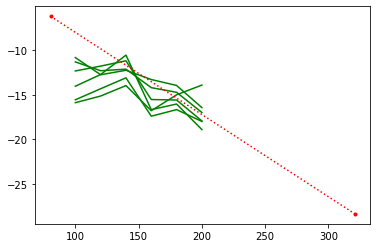

In [9]:
x = np.array([100, 120, 140, 160, 180, 200]).reshape(-1,1)

plt.plot(x, Delta_H_100, c='green')
plt.plot(x, Delta_H_120, c='green')
plt.plot(x, Delta_H_140, c='green')
plt.plot(x, Delta_H_160, c='green')
plt.plot(x, Delta_H_180, c='green')
plt.plot(x, Delta_H_200, c='green')

plt.plot([80.40102941,320.9177792], [-6.1716905,-28.36473195], c= "red", marker='.', linestyle=':')
#plt.gca().invert_yaxis()
plt.show()

In [13]:
from pyomo.environ import *
import pyomo.environ as pe

##An example will be provided that is not going to be equal to the features you should use, but will be there to modify for use.
def mat_1(x):
#   Return matrix of 1, x1, x1^2, x1^3, x1^4.  Dimension: (n_samples, 8)
    m, n = np.shape(x)
    #mat = np.array([np.ones(m), x[:,0], x[:,0]**2, x[:,0]**3, x[:,0]**4]).T
    mat = np.array([np.ones(m), x[:,0], x[:,0]**2, x[:,0]**3]).T
    return mat


# create index list for training points

points_list = np.linspace(1, 6, num=6)

feature_list = np.linspace(1, 4, num=4)

No_of_MOFs = 6

In [14]:
x = np.array([100, 120, 140, 160, 180, 200]).reshape(-1,1)
X = mat_1(x) 
xdic={}

for j in range(len(feature_list)):
    for i in range(len(points_list)):
        xdic[(i+1,j+1)]=X[i,j]    
        
Y = y.T

ydic={}

for j in range(No_of_MOFs):
    for i in range(len(points_list)):
        ydic[(i+1,j+1)]=float(Y[i,j])


parameter values:

b1:[17.25651199]

b2:[-0.78498276]

b3:[0.00584341]

b4:[-1.31069481e-05]

For lamda=1e-06, R2: 0.9977267320511448
objective function = 0.05309741674384977
[261.74597657 153.72234144  30.35685644]

parameter values:

b1:[-10.0027724]

b2:[-0.22910846]

b3:[0.00246303]

b4:[-6.94374784e-06]

For lamda=1e-06, R2: 0.9589359229779052
objective function = 0.3262572704738419
[249.95773473 148.42396385 -43.6699857 ]

parameter values:

b1:[-47.99705715]

b2:[0.59851343]

b3:[-0.00310965]

b4:[5.03344691e-06]

For lamda=1e-06, R2: 0.7293979665385304
objective function = 1.6391857272574026
[240.29630335+116.45910926j 240.29630335-116.45910926j
 137.20470466  +0.j        ]

parameter values:

b1:[21.62922922]

b2:[-0.81348923]

b3:[0.00539119]

b4:[-1.09828277e-05]

For lamda=1e-06, R2: 0.999289467019906
objective function = 0.009327113948119121
[280.08069191 172.34779826  38.44558467]

parameter values:

b1:[30.84231199]

b2:[-0.92958013]

b3:[0.00588047]

b4:[-1.17674689e-0

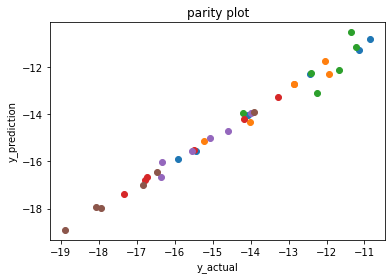

In [16]:
for k in range(1, No_of_MOFs +1):
    model = ConcreteModel()   
    #Define Data:
    model.m = points_list
    model.n = feature_list
    model.yact = ydic
    model.xs = xdic

    model.ypred = Var(model.m)

    model.b = Var(model.n)

    lamda =  0.000001

    def obj_rule(model):
        return sum((sum((model.b[j]*model.xs[i,j]) for j in model.n)-model.yact[i,k])**2 for i in model.m) + lamda*sum(abs(model.b[j]) for j in model.n)
    model.obj = Objective(rule=obj_rule) 

    #same as above:
    solver = SolverFactory('baron')
    solver.solve(model)

    s = (len(points_list),1)
    y_predict = np.zeros(s)

    for i in range(1, len(points_list)+1 ):

        for j in range(1, len(feature_list)+1):

            y_predict [i-1] = y_predict [i-1] + value(model.b[j])*value(model.xs[i,j])

    c = np.empty((len(feature_list),1))

    print('\nparameter values:')
    for i in range(len(feature_list)):
        c[i,0] = value(model.b[i+1])
        print('\nb'+str(i+1)+':'+str(c[i]))


    print('\nFor lamda='+str(lamda)+', R2: '+str(r2_score(y_predict, Y[:,k-1])))
    print('objective function =', value(model.obj))

    plt.scatter(y_predict,  Y[:,k-1])
    plt.xlabel('y_actual')
    plt.ylabel('y_prediction')
    plt.title('parity plot')
    
    #p = [value(model.b[5]), value(model.b[4]), value(model.b[3]), value(model.b[2]) + 0.0923, value(model.b[1]) - 1.2471]
    p = [value(model.b[4]), value(model.b[3]), value(model.b[2]) + 0.0923, value(model.b[1]) - 1.2471]
    roots = np.roots(p)
    print(roots)


In [17]:
R2= []
T = []
for k in range(1, No_of_MOFs +1):
    model = ConcreteModel()   
    #Define Data:
    model.m = points_list
    model.n = feature_list
    model.yact = ydic
    model.xs = xdic

    model.ypred = Var(model.m)

    model.b = Var(model.n)

    lamda =  0.000001

    def obj_rule(model):
        return sum((sum((model.b[j]*model.xs[i,j]) for j in model.n)-model.yact[i,k])**2 for i in model.m) + lamda*sum(abs(model.b[j]) for j in model.n)
    model.obj = Objective(rule=obj_rule) 

    #same as above:
    solver = SolverFactory('baron')
    solver.solve(model)

    s = (len(points_list),1)
    y_predict = np.zeros(s)

    for i in range(1, len(points_list)+1 ):

        for j in range(1, len(feature_list)+1):

            y_predict [i-1] = y_predict [i-1] + value(model.b[j])*value(model.xs[i,j])

    c = np.empty((len(feature_list),1))

#     print('\nparameter values:')
#     for i in range(len(feature_list)):
#         c[i,0] = value(model.b[i+1])
#         print('\nb'+str(i+1)+':'+str(c[i]))


#     print('\nFor lamda='+str(lamda)+', R2: '+str(r2_score(y_predict, Y[:,k-1])))
#     print('objective function =', value(model.obj))

#     plt.scatter(y_predict,  Y[:,k-1])
#     plt.xlabel('y_actual')
#     plt.ylabel('y_prediction')
#     plt.title('parity plot')

    R2.append(r2_score(y_predict, Y[:,k-1]))
    
    p = [value(model.b[5]), value(model.b[4]), value(model.b[3]), value(model.b[2]) + 0.0923, value(model.b[1]) - 1.2471]
    roots = np.roots(p)
    for i in range(len(roots)):
        
        if roots[i].imag == 0 and 100 < roots[i].real < 300:
            T.append(roots[i])
            


KeyError: "Index '5' is not valid for indexed component 'b'"

In [ ]:
print(R2)
print(T)